**Load the libraries**


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
import string
from collections import Counter

Load the dataset

In [ ]:
df=pd.read_csv('/content/dataset/combined_emotion.csv')

EDA

In [ ]:
print(df.head())

                                            sentence emotion
0      i just feel really helpless and heavy hearted    fear
1  ive enjoyed being able to slouch about relax a...     sad
2  i gave up my internship with the dmrg and am f...    fear
3                         i dont know i feel so lost     sad
4  i am a kindergarten teacher and i am thoroughl...    fear


View some sample data

In [ ]:
print(df.sample(10))

                                                 sentence emotion
107442  i spend less time in the sunlight in the winte...     sad
204304  i am trying to stay strong i try to stay posit...     sad
260379  i actually have time and feel more creative i ...     joy
2514    i just feel that i should be more outgoing mee...     joy
400245  i feel uncertain or as if i took a wrong turn ...    fear
258220  i love my you keep me feel so creative lady ga...     joy
311859  i did my best to be a gracious hostess even fe...     sad
87599   i felt that the years have pushed me further a...    love
349657  i felt that woolf explored feelings such as re...    love
331895  i was coming to the end of it reading in bed o...     sad


Check the data null values and the column with row

In [ ]:
print(f"Dataframe size: {df.shape}")
print(df.isnull().sum())

Dataframe size: (422746, 2)
sentence    0
emotion     0
dtype: int64


Show the datasets in bar chart

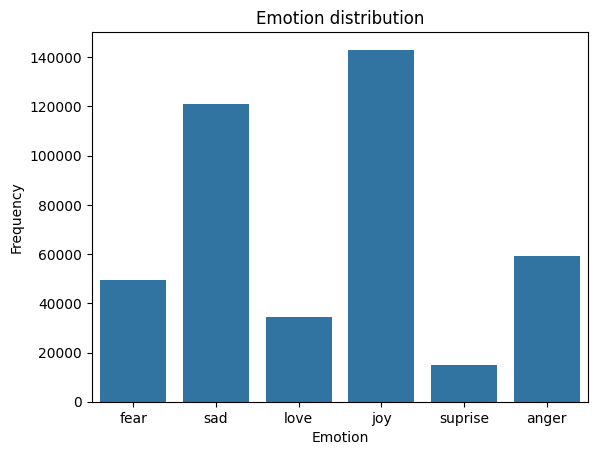

In [ ]:
sns.countplot(data=df, x='emotion')
plt.title('Emotion distribution')
plt.xlabel('Emotion')
plt.ylabel('Frequency')
plt.show()

Show the datasets via value per feature

In [ ]:
class_counts = df['emotion'].value_counts()
print(class_counts)

emotion
joy        143067
sad        121187
anger       59317
fear        49649
love        34554
suprise     14972
Name: count, dtype: int64


Some useful insights on the sentences of the dataset

We are creating a column with sentences length

In [ ]:
# Add column with sentence length (including spaces)
df['sentence_length'] = df['sentence'].apply(len)

Show the length of the sentences via bar chart

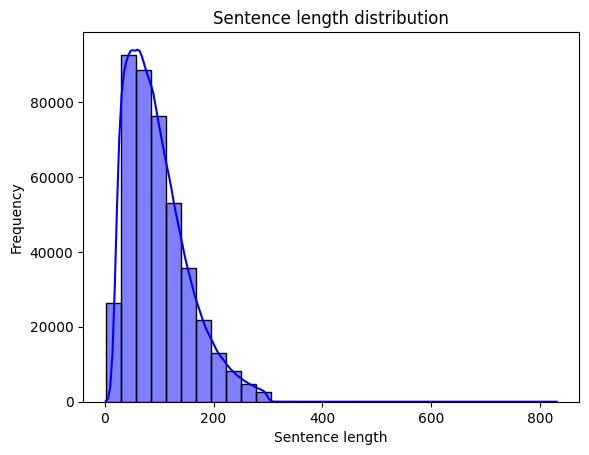

In [ ]:
# Show distribution of sentence length
sns.histplot(df['sentence_length'], bins=30, kde=True, color='blue')
plt.title('Sentence length distribution')
plt.xlabel('Sentence length')
plt.ylabel('Frequency')
plt.show()



Show the neccessary information on sentences

In [ ]:
# Show sentence length statistics
print(df['sentence_length'].describe())

count    422746.000000
mean         97.033980
std          56.198156
min           2.000000
25%          54.000000
50%          86.000000
75%         128.000000
max         830.000000
Name: sentence_length, dtype: float64


From the sentences column we can consider the max length sentences is 830 character and small length is 2

We can see the sentence_length is also coming with value

In [ ]:
print(df.head())

                                            sentence emotion  sentence_length
0      i just feel really helpless and heavy hearted    fear               45
1  ive enjoyed being able to slouch about relax a...     sad              234
2  i gave up my internship with the dmrg and am f...    fear               63
3                         i dont know i feel so lost     sad               26
4  i am a kindergarten teacher and i am thoroughl...    fear              222


Showing each emotion per average sentences length

In [ ]:
avg_length_by_emotion = df.groupby('emotion')['sentence_length'].mean().reset_index()

Showing via bar chart

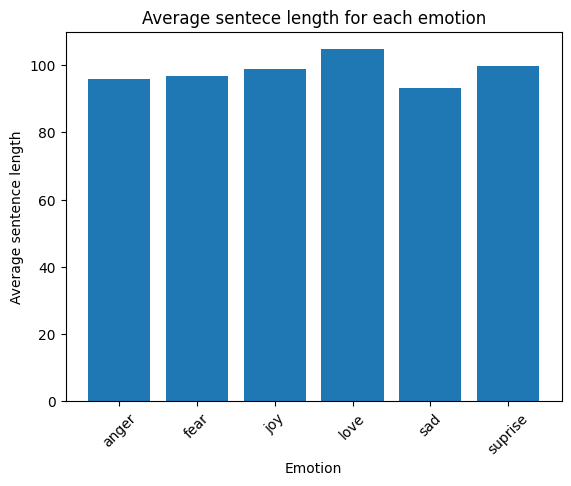

In [ ]:
plt.bar(avg_length_by_emotion['emotion'], avg_length_by_emotion['sentence_length'])
plt.xlabel("Emotion")
plt.ylabel("Average sentence length")
plt.title("Average sentece length for each emotion")
plt.xticks(rotation=45)
plt.show()

Download the nltk libraries

In [ ]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Text Preprocessing techniques

In [ ]:
def preprocess_text(text):
    text = text.lower()
    # Remove punctuation
    text = ''.join([char for char in text if char not in string.punctuation])
    # Tokenize sentences
    tokens = word_tokenize(text)
    # Delete stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

In [ ]:
all_words = []
for sentence in df['sentence']:
    all_words.extend(preprocess_text(sentence))


Show the top 20 most popular words from the dataset

In [ ]:
max_Words = 20 # number of most popular words

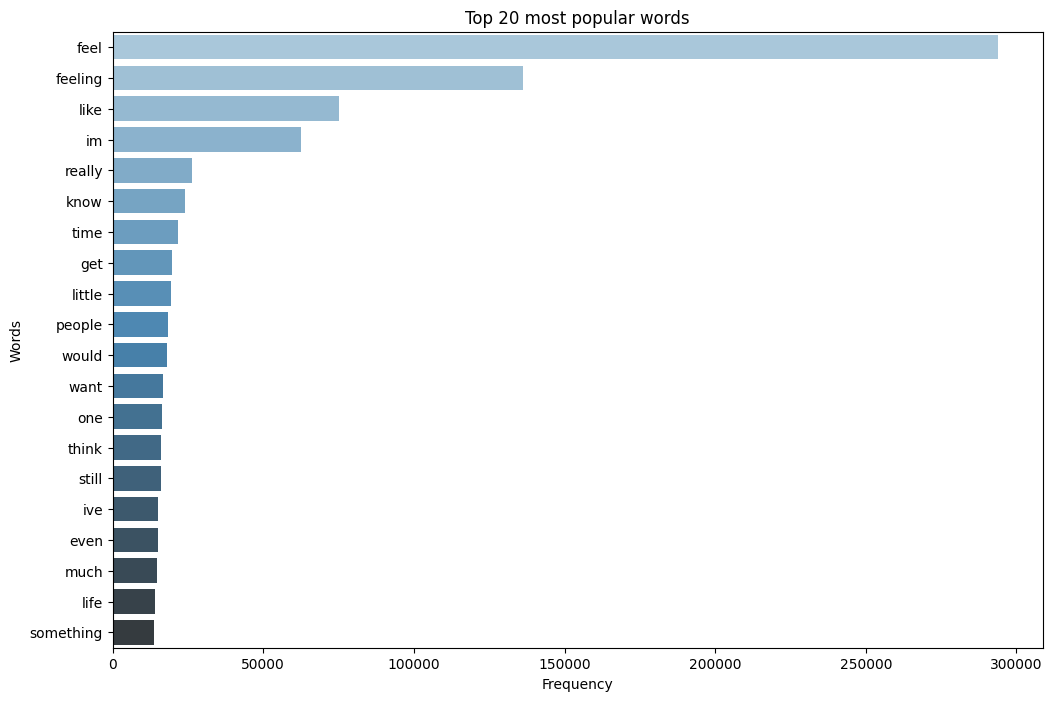

In [ ]:
word_freq = Counter(all_words)
common_words = word_freq.most_common(max_Words)

x = [word[1] for word in common_words] # popular words
y = [word[0] for word in common_words] # frequency of popular words

plt.figure(figsize=(12, 8))
sns.barplot(x=x, y=y, hue=y, palette='Blues_d', legend=False)
plt.title(f'Top {max_Words} most popular words')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

Show the top 10 words from each emotions

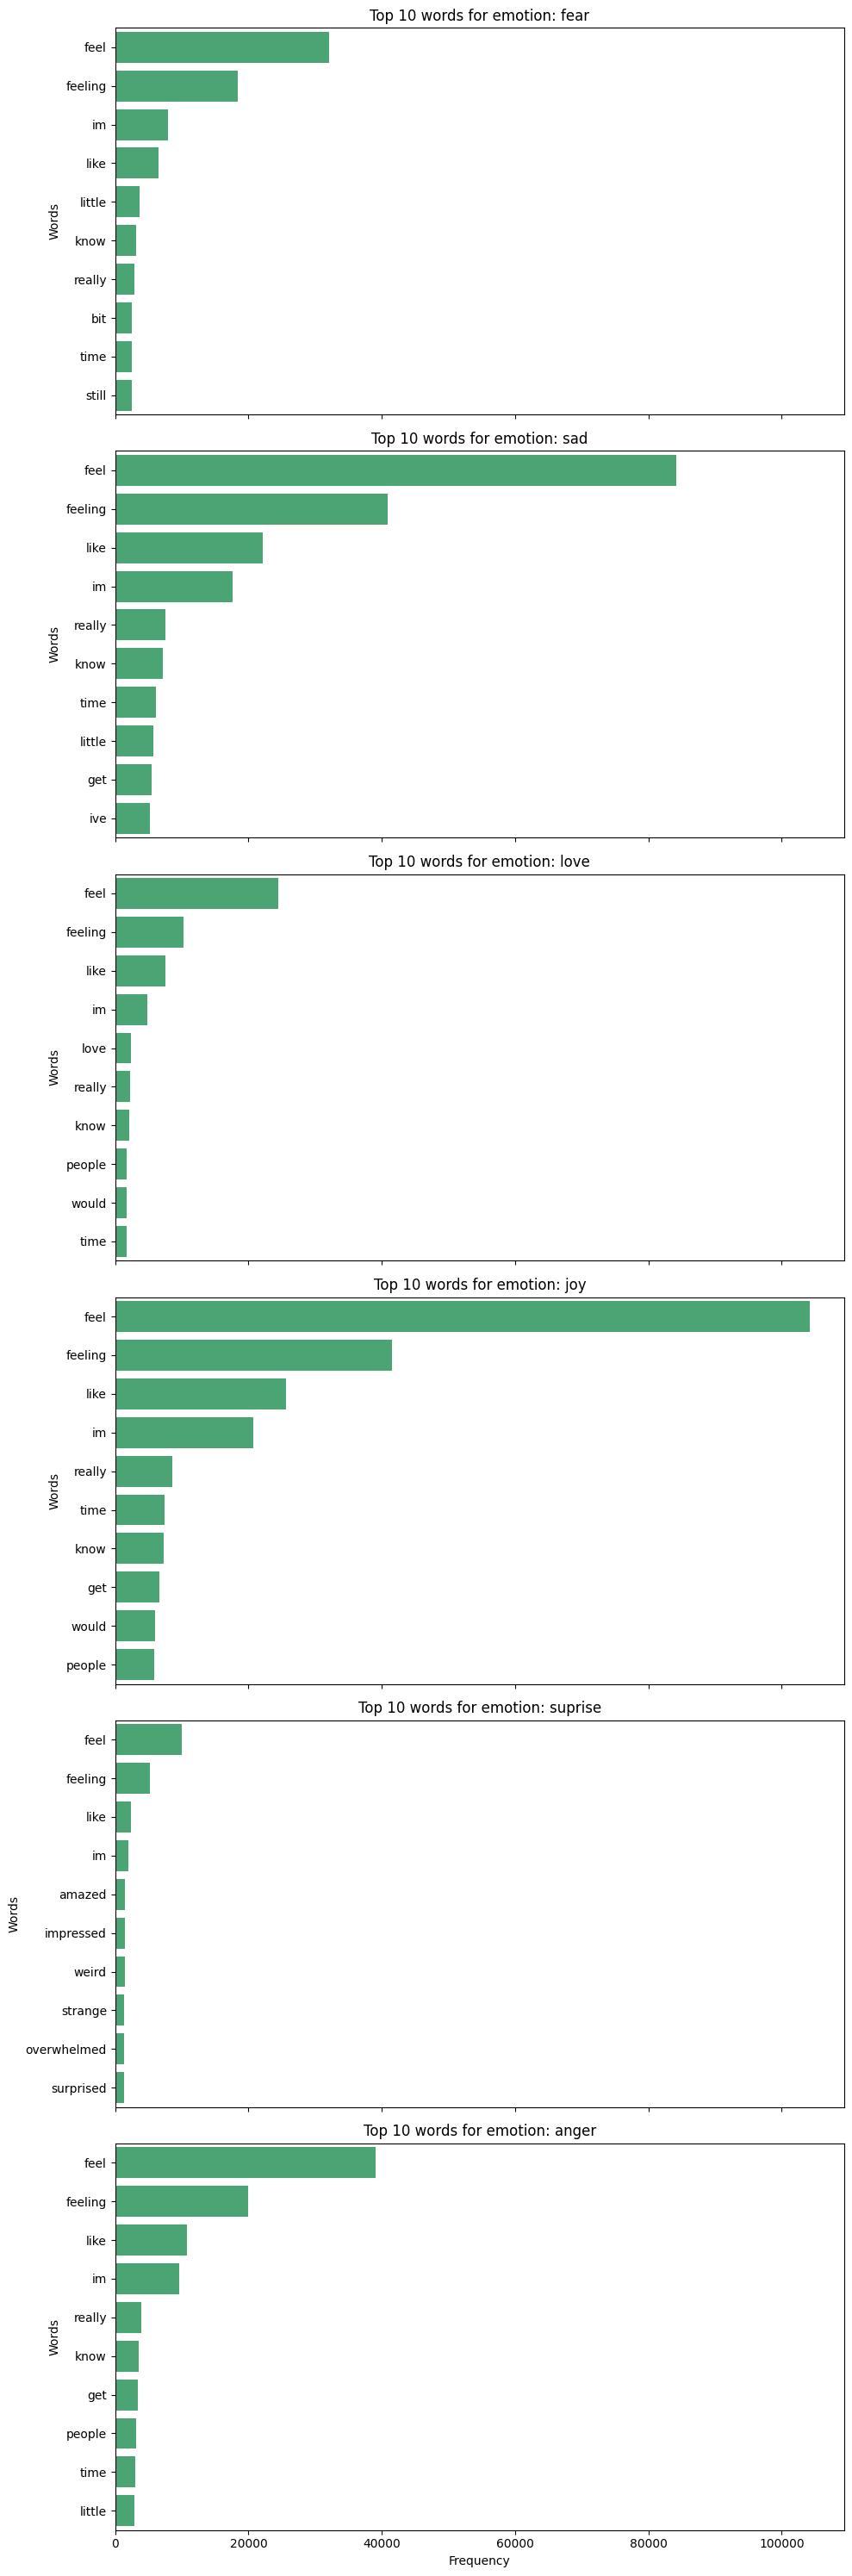

In [ ]:
emotion_word_freq = {}
for emotion in df['emotion'].unique():
    # Filter by emotions
    subset = df[df['emotion'] == emotion]['sentence']
    words = []
    for sentence in subset:
        words.extend(preprocess_text(sentence))
    emotion_word_freq[emotion] = Counter(words).most_common(10)

# Show frequency of popular words for each emotion
num_emotions = len(emotion_word_freq)
fig, axes = plt.subplots(nrows=num_emotions, figsize=(10, 5 * num_emotions), sharex=True)

for i, (emotion, freq) in enumerate(emotion_word_freq.items()):
    words, counts = zip(*freq)  # seperate words from their frequency
    ax = axes[i] if num_emotions > 1 else axes
    sns.barplot(x=list(counts), y=list(words), color='mediumseagreen', ax=ax)
    ax.set_title(f'Top 10 words for emotion: {emotion}')
    ax.set_xlabel('Frequency')
    ax.set_ylabel('Words')

plt.tight_layout()
plt.show()

show the datasets

In [ ]:
print(df.head())

                                            sentence emotion  sentence_length
0      i just feel really helpless and heavy hearted    fear               45
1  ive enjoyed being able to slouch about relax a...     sad              234
2  i gave up my internship with the dmrg and am f...    fear               63
3                         i dont know i feel so lost     sad               26
4  i am a kindergarten teacher and i am thoroughl...    fear              222


Split the datasets into train and test datasets

In [ ]:
# Seperate sentences and target
X = df["sentence"]
y = df["emotion"]

# Split on train and test (stratification is needed due to imbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Do the vectorization

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

Apply class weight logistic Regression

In [ ]:
model = LogisticRegression( solver='lbfgs', class_weight='balanced', max_iter=200)
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9019278533412182

Classification report:
               precision    recall  f1-score   support

       anger       0.88      0.93      0.91     11863
        fear       0.86      0.86      0.86      9930
         joy       0.98      0.88      0.92     28614
        love       0.72      0.96      0.83      6911
         sad       0.97      0.91      0.94     24238
     suprise       0.65      0.93      0.77      2994

    accuracy                           0.90     84550
   macro avg       0.84      0.91      0.87     84550
weighted avg       0.91      0.90      0.90     84550

